# Decision Tree from Scratch

The aim of this notebook is to implement the **decision tree** algorithm for scratch using only NumPy. 

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
# Generate synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=42)

In [3]:
X.shape, y.shape

((100, 2), (100,))

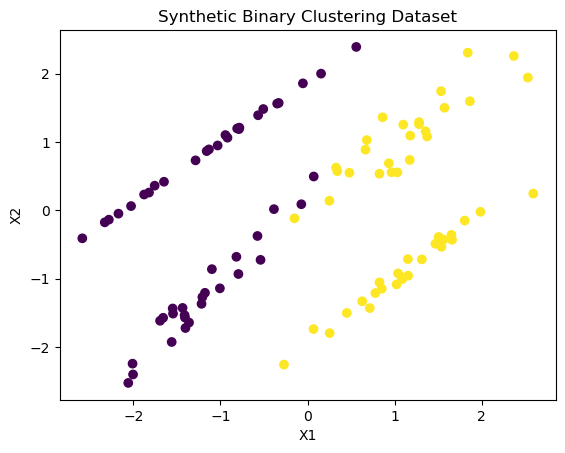

In [4]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Binary Clustering Dataset")
plt.show()

In [5]:
# Selection of X first's feature
X1 = X[:, 0]

In [6]:
# Compute threshold candidatures (midpoints between sorted unique values)
X1_thresholds = np.unique(X1)[:-1] + np.diff(np.unique(X1)) / 2 

In [7]:
X1_thresholds[:5]

array([-2.45695158, -2.30469035, -2.22621946, -2.11468677, -2.04232075])

In [8]:
# Entropy function
def entropy(y):
    if len(y) == 0:
        return 0
    p = np.mean(y)
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

In [9]:
# Tests
print("Entropy for pure class 0:", entropy(np.array([0, 0, 0, 0])))
print("Entropy for pure class 1:", entropy(np.array([1, 1, 1, 1])))
print("Entropy for mixed classes:", entropy(np.array([0, 1, 0, 1])))
print("Entropy for mixed classes:", entropy(np.array([0, 1, 0, 1, 1])))


Entropy for pure class 0: 0
Entropy for pure class 1: 0
Entropy for mixed classes: 1.0
Entropy for mixed classes: 0.9709505944546686


In [10]:
# Information Gain function
def information_gain(y, y_left, y_right):
    parent_entropy = entropy(y)
    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)
    
    if n == 0:
        return 0
    
    weighted_child_entropy = (n_left / n) * entropy(y_left) + (n_right / n) * entropy(y_right)
    
    return parent_entropy - weighted_child_entropy

In [11]:
# Tests
print("Information Gain for split:", information_gain(np.array([0, 1, 0, 1]), np.array([0, 0]), np.array([1, 1])))
print("Information Gain for pure class 0 and class 1:", information_gain(np.array([0, 0, 0, 0]), np.array([0, 0]), np.array([1, 1])))

Information Gain for split: 1.0
Information Gain for pure class 0 and class 1: 0.0


In [12]:
# Find the best threshold for a feature
def best_threshold(X_feature, y):
    # Compute threshold candidatures (midpoints between sorted unique values)
    thresholds = np.unique(X_feature)[:-1] + np.diff(np.unique(X_feature)) / 2
    best_gain = -np.inf
    best_thresh = None
    
    # For each threshold, split y into left and right subsets 
    for thresh in thresholds:
        y_left = y[X_feature <= thresh]
        y_right = y[X_feature > thresh]
        
        # Compute information gain for this split
        gain = information_gain(y, y_left, y_right)
        
        # Return the threshold with the highest gain
        if gain > best_gain:
            best_gain = gain
            best_thresh = thresh
            
    return best_thresh, best_gain

In [13]:
# Test with X1
best_thresh, best_gain = best_threshold(X1, y)
print("Best threshold for X1:", best_thresh)
print("Best information gain for X1:", best_gain)

Best threshold for X1: 0.20286009456201243
Best information gain for X1: 0.7644028051470533


In [14]:
# Find the best split along all features
def best_split(X, y):
    best_gain = -np.inf
    best_feature = None
    best_thresh = None
    
    n_features = X.shape[1]
    
    # For each feature, find the best threshold and gain
    for feature in range(n_features):
        X_feature = X[:, feature]
        thresh, gain = best_threshold(X_feature, y)
        
        if gain > best_gain:
            best_gain = gain
            best_feature = feature
            best_thresh = thresh
            
    return best_feature, best_thresh, best_gain

In [15]:
# Test with the whole dataset
best_feature, best_thresh, best_gain = best_split(X, y)
print("Best feature index:", best_feature)
print("Best threshold for best feature:", best_thresh)
print("Best information gain for best feature:", best_gain)

Best feature index: 0
Best threshold for best feature: 0.20286009456201243
Best information gain for best feature: 0.7644028051470533


In [16]:
# Recursive tree building function
def build_tree(X, y, depth=0, max_depth=5): 
    # Base case: if all labels are the same or max depth reached, return a leaf node
    if len(np.unique(y)) == 1 or depth >= max_depth:
        return np.mean(y) > 0.5  # Return the majority class
    
    # Find the best split
    feature, thresh, gain = best_split(X, y)
    
    if gain == 0:
        return np.mean(y) > 0.5  # Return the majority class if no gain
    
    # Split the dataset
    left_indices = X[:, feature] <= thresh
    right_indices = X[:, feature] > thresh
    
    # Recursively build left and right subtrees
    left_subtree = build_tree(X[left_indices], y[left_indices], depth + 1, max_depth)
    right_subtree = build_tree(X[right_indices], y[right_indices], depth + 1, max_depth)
    
    return (feature, thresh, left_subtree, right_subtree)

In [17]:
# Test with the whole dataset
build_tree(X, y)

(0,
 np.float64(0.20286009456201243),
 (0,
  np.float64(-0.3009999645228756),
  np.False_,
  (1, np.float64(-0.014062378177729817), np.True_, np.False_)),
 (1, np.float64(2.3465968603078835), np.True_, np.False_))

The tree has been built. We can read the structure:

- **Root**: split on feature 0 at a threshold of 0.20
- **Left branch**: re-split on feature 0 at a threshold of -0.30, then...
- **Right branch**: re-split on feature 1 at a threshold of 2.34...

```plaintext
(0, 0.20, ..., ...)        ← node: if x[0] <= 0.20 → left, otherwise → right
        ↓ left
(0, -0.30, False, ...)     ← node: if x[0] <= -0.30 → False (leaf), otherwise → ...
        ↓ right
False                      ← leaf: class 0
```

How can we tell if we're at a leaf or a node? A **node** is a **tuple** and a **leaf** is a **boolean**.

The leaves are True (class 1) or False (class 0).

In [18]:
# Iterate through the tree for a single example x (a 1D vector)
def predict_one(tree, x):
    # Checks if the tree is a leaf node (boolean) and returns the prediction
    if isinstance(tree, (bool, np.bool_)):
        return tree

    # Unpack the tree node
    feature, thresh, left_subtree, right_subtree = tree

    # For each sample, traverse the tree based on the feature and threshold
    if x[feature] <= thresh:
        return predict_one(left_subtree, x)
    else:
        return predict_one(right_subtree, x)

In [19]:
# Prediction function (iterate through the tree for each example in X)
def predict(tree, X):
    return np.array([predict_one(tree, x) for x in X])

In [20]:
# Test on the dataset
tree = build_tree(X, y)
predictions = predict(tree, X)

In [21]:
print("Accuracy:", accuracy_score(y, predictions))
print("Confusion Matrix:\n", confusion_matrix(y, predictions))
print("Classification Report:\n", classification_report(y, predictions))

Accuracy: 1.0
Confusion Matrix:
 [[50  0]
 [ 0 50]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [26]:
# Real test by splitting the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Train the tree on the training set
tree = build_tree(X_train, y_train)

In [28]:
# Predict on the test set
predictions = predict(tree, X_test)

In [29]:
print("Train Accuracy:", accuracy_score(y_train, predict(tree, X_train)))
print("Train Confusion Matrix:\n", confusion_matrix(y_train, predict(tree, X_train)))
print("Train Classification Report:\n", classification_report(y_train, predict(tree, X_train)))

Train Accuracy: 1.0
Train Confusion Matrix:
 [[39  0]
 [ 0 41]]
Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        41

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [30]:
print("TestAccuracy:", accuracy_score(y_test, predictions))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, predictions))
print("Test Classification Report:\n", classification_report(y_test, predictions))

TestAccuracy: 0.95
Test Confusion Matrix:
 [[10  1]
 [ 0  9]]
Test Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.90      1.00      0.95         9

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20



100% training, 95% testing is good. There’s a slight visible **overfitting**, which is normal for a tree.